# EDA — Sistema inteligente de priorización de cobranzas

**Proyecto integrador de Inteligencia Artificial**  
**Tema:** priorización inteligente de cobranzas para empresas que venden a crédito.

Este notebook desarrolla el **Análisis Exploratorio de Datos (EDA)** del proyecto con base en la guía de implementación, la rúbrica entregada y el contexto final de la fase de generación de datos. La estructura cubre:

1. Comprensión del dataset  
2. Revisión de calidad de datos  
3. Estadísticas descriptivas  
4. Análisis de distribuciones  
5. Identificación de outliers  
6. Análisis de correlaciones  
7. Análisis de variables categóricas  
8. Relaciones entre variables  
9. Riesgos para modelado y decisiones metodologicas

## Decisión predictiva que habilita el dataset

El dataset habilita una decisión concreta de negocio: **priorizar facturas para gestión de cobranza según su riesgo esperado de mora**. Para cada `factura_id` y `fecha_corte`, el sistema debe estimar si la factura terminará en `on_time`, `+30`, `+60` o `+90`. Esa predicción permite ordenar casos, definir intensidad de contacto y alimentar una estrategia de cobranza diferenciada.

## Contexto del sistema

El sistema tiene tres componentes funcionales:

- **Componente 1:** predicción de mora por factura, en clases `on_time`, `+30`, `+60` y `+90`.
- **Componente 2:** segmentación de clientes para asignar estrellas de 1 a 5 según su comportamiento histórico.
- **Componente 3:** decisor de acción de cobranza basado en reglas de negocio.

La **unidad principal de predicción** es la **factura**, pero el dataset de modelado trabaja con **cortes temporales**. Esto significa que una misma factura puede tener varias filas en `features_ml`, una por cada momento de scoring. Por esa razón, cualquier partición train/test posterior debe hacerse por `factura_id` y no por fila.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
# Localizaci?n robusta de archivos de entrada
BASE = Path.cwd().resolve()

def locate_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / '01_generacion' / 'data' / 'features_ml.csv').exists() and (candidate / '02_eda').exists():
            return candidate
    raise FileNotFoundError('No se pudo localizar la ra?z del proyecto con 01_generacion/data/features_ml.csv y 02_eda')

PROJECT_ROOT = locate_project_root(BASE)
DATA_DIR = PROJECT_ROOT / '01_generacion' / 'data'
PHASE_DIR = PROJECT_ROOT / '02_eda'
OUTPUTS_DIR = PHASE_DIR / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

def require_canonical_file(name):
    p = DATA_DIR / name
    if not p.exists():
        raise FileNotFoundError(f'No se encontró el archivo canónico requerido: {p.relative_to(PROJECT_ROOT)}')
    return p

clientes_path  = require_canonical_file('clientes.csv')
facturas_path  = require_canonical_file('facturas.csv')
gestiones_path = require_canonical_file('gestiones_cobranza.csv')
promesas_path  = require_canonical_file('promesas_pago.csv')
features_path  = require_canonical_file('features_ml.csv')

clientes  = pd.read_csv(clientes_path)
facturas  = pd.read_csv(facturas_path, parse_dates=['fecha_emision', 'fecha_vencimiento', 'fecha_pago_real'])
gestiones = pd.read_csv(gestiones_path, parse_dates=['fecha_gestion'])
promesas  = pd.read_csv(promesas_path, parse_dates=['fecha_promesa', 'fecha_compromiso'])
features  = pd.read_csv(features_path, parse_dates=['fecha_corte'])

TARGET_COL = 'target_mora'
fact_target_col = TARGET_COL
features_target_col = TARGET_COL

required_features_ml_columns = {
    'factura_id', 'cliente_id', 'num_corte', 'fecha_corte', TARGET_COL,
    'monto', 'condicion_dias', 'antiguedad_meses', 'tiene_garantia',
    'sector_retail', 'sector_manufactura', 'sector_servicios',
    'sector_construccion', 'sector_agro', 'sector_tecnologia',
    'sector_salud', 'sector_transporte',
    'num_facturas_prev', 'mora_promedio_hist', 'mora_ultimo_tramo',
    'tasa_cumplimiento', 'monto_promedio_hist', 'ratio_monto',
    'moras_consecutivas', 'num_gestiones_factura', 'dias_desde_ultima_gestion',
    'dias_desde_emision', 'dias_hasta_vence', 'tasa_contacto_cliente',
    'ultimo_resultado_enc', 'num_no_contesta_cons', 'tiene_disputa_activa',
    'tiene_promesa_activa', 'num_promesas_rotas', 'tasa_cumpl_promesas',
    'promesas_total'
}

required_columns = {
    'clientes': {'cliente_id', 'nombre', 'sector', 'antiguedad_meses', 'tiene_garantia', 'perfil_pago'},
    'facturas': {'factura_id', 'cliente_id', 'fecha_emision', 'fecha_vencimiento', 'fecha_pago_real', 'condicion_dias', 'monto', fact_target_col, 'dias_mora_real'},
    'gestiones': {'gestion_id', 'factura_id', 'cliente_id', 'fecha_gestion', 'canal', 'contacto_exitoso', 'resultado', 'motivo_no_pago', 'dias_mora_en_gestion'},
    'promesas': {'promesa_id', 'gestion_id', 'factura_id', 'cliente_id', 'fecha_promesa', 'fecha_compromiso', 'se_cumplio'},
    'features_ml': required_features_ml_columns,
}

loaded_tables = {
    'clientes': clientes,
    'facturas': facturas,
    'gestiones': gestiones,
    'promesas': promesas,
    'features_ml': features,
}

missing_columns = []
for table_name, expected in required_columns.items():
    missing = sorted(expected - set(loaded_tables[table_name].columns))
    if missing:
        missing_columns.append({'dataset': table_name, 'columnas_faltantes': ', '.join(missing)})

if missing_columns:
    display(pd.DataFrame(missing_columns))
    raise ValueError('Existen columnas requeridas faltantes; no se puede continuar el EDA.')

print('Directorio de entrada:', DATA_DIR.relative_to(PROJECT_ROOT))
print('Directorio de fase EDA:', PHASE_DIR.relative_to(PROJECT_ROOT))
print('Directorio de outputs EDA:', OUTPUTS_DIR.relative_to(PROJECT_ROOT))
print('Archivos cargados correctamente:')
for p in [clientes_path, facturas_path, gestiones_path, promesas_path, features_path]:
    print('-', p.relative_to(PROJECT_ROOT))
print('Target en facturas:', fact_target_col)
print('Target en features_ml:', features_target_col)


Directorio de entrada: 01_generacion\data
Directorio de fase EDA: 02_eda
Directorio de outputs EDA: 02_eda\outputs
Archivos cargados correctamente:
- 01_generacion\data\clientes.csv
- 01_generacion\data\facturas.csv
- 01_generacion\data\gestiones_cobranza.csv
- 01_generacion\data\promesas_pago.csv
- 01_generacion\data\features_ml.csv
Target en facturas: target_mora
Target en features_ml: target_mora


## 1. Comprensión del dataset

In [3]:

# Resumen general de datasets
resumen_dataset = pd.DataFrame([
    {'dataset': 'clientes',  'filas': len(clientes),  'columnas': clientes.shape[1]},
    {'dataset': 'facturas',  'filas': len(facturas),  'columnas': facturas.shape[1]},
    {'dataset': 'gestiones', 'filas': len(gestiones), 'columnas': gestiones.shape[1]},
    {'dataset': 'promesas',  'filas': len(promesas),  'columnas': promesas.shape[1]},
    {'dataset': 'features_ml','filas': len(features), 'columnas': features.shape[1]},
])

display(resumen_dataset)


,dataset,filas,columnas
0,clientes,200,6
1,facturas,5338,9
2,gestiones,14333,9
3,promesas,1741,7
4,features_ml,19671,36


In [4]:

# Perfil estructural de cada tabla

def profile_df(df):
    return pd.DataFrame({
        'columna': df.columns,
        'tipo': [str(df[c].dtype) for c in df.columns],
        'nulos': [int(df[c].isna().sum()) for c in df.columns],
        'pct_nulos': [round(df[c].isna().mean()*100, 2) for c in df.columns],
        'unicos': [int(df[c].nunique(dropna=True)) for c in df.columns],
    })

for nombre, df in [('clientes', clientes), ('facturas', facturas), ('gestiones', gestiones), ('promesas', promesas), ('features_ml', features)]:
    display(Markdown(f'### {nombre}'))
    display(profile_df(df))


### clientes

,columna,tipo,nulos,pct_nulos,unicos
0,cliente_id,str,0,0.0000,200
1,nombre,str,0,0.0000,200
2,sector,str,0,0.0000,8
3,antiguedad_meses,int64,0,0.0000,66
4,tiene_garantia,int64,0,0.0000,2
5,perfil_pago,str,0,0.0000,4


### facturas

,columna,tipo,nulos,pct_nulos,unicos
0,factura_id,str,0,0.0000,5338
1,cliente_id,str,0,0.0000,200
2,fecha_emision,datetime64[us],0,0.0000,730
3,fecha_vencimiento,datetime64[us],0,0.0000,784
4,fecha_pago_real,datetime64[us],0,0.0000,831
5,condicion_dias,int64,0,0.0000,4
6,monto,float64,0,0.0000,5337
7,target_mora,str,0,0.0000,4
8,dias_mora_real,int64,0,0.0000,121


### gestiones

,columna,tipo,nulos,pct_nulos,unicos
0,gestion_id,str,0,0.0000,14333
1,factura_id,str,0,0.0000,4221
2,cliente_id,str,0,0.0000,200
3,fecha_gestion,datetime64[us],0,0.0000,884
4,canal,str,0,0.0000,5
5,contacto_exitoso,int64,0,0.0000,2
6,resultado,str,0,0.0000,9
7,motivo_no_pago,str,9283,64.7700,7
8,dias_mora_en_gestion,int64,0,0.0000,121


### promesas

,columna,tipo,nulos,pct_nulos,unicos
0,promesa_id,str,0,0.0000,1741
1,gestion_id,str,0,0.0000,1741
2,factura_id,str,0,0.0000,1405
3,cliente_id,str,0,0.0000,189
4,fecha_promesa,datetime64[us],0,0.0000,704
5,fecha_compromiso,datetime64[us],0,0.0000,714
6,se_cumplio,int64,0,0.0000,2


### features_ml

,columna,tipo,nulos,pct_nulos,unicos
0,factura_id,str,0,0.0000,5338
1,cliente_id,str,0,0.0000,200
2,num_corte,int64,0,0.0000,11
3,fecha_corte,datetime64[us],0,0.0000,900
4,monto,float64,0,0.0000,5337
5,condicion_dias,int64,0,0.0000,4
6,antiguedad_meses,int64,0,0.0000,66
7,tiene_garantia,int64,0,0.0000,2
8,sector_retail,int64,0,0.0000,2
9,sector_manufactura,int64,0,0.0000,2



### Interpretación inicial

- `clientes`, `facturas`, `gestiones_cobranza` y `promesas_pago` conforman el modelo transaccional del problema.
- `features_ml` es el dataset de entrenamiento del componente 1 y trabaja con **cortes temporales**, por lo que tiene más filas que `facturas`.
- En este proyecto, el análisis principal para modelado se realizará sobre `features_ml`, mientras que las tablas base se usan para validar consistencia, trazabilidad y lógica de negocio.


### Decisión analítica derivada de la comprensión del dataset

La lectura del dataset confirma que el objetivo predictivo no es describir clientes de forma aislada, sino **clasificar el riesgo final de mora de cada factura en cada corte temporal disponible**. La salida esperada del modelo será una clase de riesgo (`on_time`, `+30`, `+60`, `+90`) que luego se traducirá en prioridad operativa de cobranza.

Implicaciones directas:

- La evaluación debe respetar la unidad `factura_id`, porque una factura puede repetirse en varios cortes.
- `target_mora` solo puede usarse como etiqueta, nunca como predictor.
- Variables disponibles en el corte (`fecha_corte`) son válidas; información posterior al corte sería fuga temporal.
- `perfil_pago` sirve para validar la simulación, pero debe excluirse del dataset final si representa una etiqueta interna artificial.


## 2. Revisión de la calidad de los datos

In [5]:

# Duplicados, unicidad e integridad referencial
quality_checks = {
    'clientes_duplicate_rows': int(clientes.duplicated().sum()),
    'facturas_duplicate_rows': int(facturas.duplicated().sum()),
    'gestiones_duplicate_rows': int(gestiones.duplicated().sum()),
    'promesas_duplicate_rows': int(promesas.duplicated().sum()),
    'features_duplicate_rows': int(features.duplicated().sum()),
    'cliente_id_unique': bool(clientes['cliente_id'].is_unique),
    'factura_id_unique': bool(facturas['factura_id'].is_unique),
    'gestion_id_unique': bool(gestiones['gestion_id'].is_unique),
    'promesa_id_unique': bool(promesas['promesa_id'].is_unique),
    'factura_cliente_fk_missing': int((~facturas['cliente_id'].isin(clientes['cliente_id'])).sum()),
    'gestion_factura_fk_missing': int((~gestiones['factura_id'].isin(facturas['factura_id'])).sum()),
    'promesa_gestion_fk_missing': int((~promesas['gestion_id'].isin(gestiones['gestion_id'])).sum()),
    'promesa_factura_fk_missing': int((~promesas['factura_id'].isin(facturas['factura_id'])).sum()),
}

quality_df = pd.DataFrame(quality_checks.items(), columns=['validacion', 'resultado'])
display(quality_df)


,validacion,resultado
0,clientes_duplicate_rows,0
1,facturas_duplicate_rows,0
2,gestiones_duplicate_rows,0
3,promesas_duplicate_rows,0
4,features_duplicate_rows,0
5,cliente_id_unique,True
6,factura_id_unique,True
7,gestion_id_unique,True
8,promesa_id_unique,True
9,factura_cliente_fk_missing,0


In [6]:
# Consistencia temporal
fact_id_num = facturas['factura_id'].str.extract(r'(\d+)').astype(int)
chrono_monotonic = facturas.assign(factura_num=fact_id_num)[['factura_num', 'fecha_emision']].sort_values('factura_num')['fecha_emision'].is_monotonic_increasing

facturas_para_gestiones = facturas[['factura_id', 'fecha_emision', 'fecha_pago_real', 'fecha_vencimiento']]
gestiones_con_factura = gestiones.merge(facturas_para_gestiones, on='factura_id', how='left')
features_con_factura = features.merge(facturas[['factura_id', 'fecha_emision', 'fecha_pago_real']], on='factura_id', how='left')

map_target_from_days = pd.cut(
    facturas['dias_mora_real'],
    bins=[-np.inf, 0, 30, 60, np.inf],
    labels=['on_time', '+30', '+60', '+90'],
    right=True,
).astype(str)

temporal_checks = {
    'fact_venc_before_emision': int((facturas['fecha_vencimiento'] < facturas['fecha_emision']).sum()),
    'fact_pago_before_emision': int((facturas['fecha_pago_real'] < facturas['fecha_emision']).sum()),
    'fact_id_chrono_monotonic': bool(chrono_monotonic),
    'target_consistente_con_dias_mora_real': int((facturas[fact_target_col] != map_target_from_days).sum()),
    'gest_before_emision': int((gestiones_con_factura['fecha_gestion'] < gestiones_con_factura['fecha_emision']).sum()),
    'gest_after_pago': int((gestiones_con_factura['fecha_gestion'] > gestiones_con_factura['fecha_pago_real']).sum()),
    'fecha_corte_before_emision': int((features_con_factura['fecha_corte'] < features_con_factura['fecha_emision']).sum()),
    'fecha_corte_after_pago': int((features_con_factura['fecha_corte'] > features_con_factura['fecha_pago_real']).sum()),
    'target_no_unico_por_factura_en_features': int((features.groupby('factura_id')[features_target_col].nunique() > 1).sum()),
}

resultados_no_contacto = {'no_contesta', 'numero_invalido', 'cliente_ausente'}
resultados_contacto = {'pagado', 'promesa_de_pago', 'disputa_monto', 'rechazo_pago', 'en_proceso_interno', 'confirma_pago'}

temporal_checks['bad_result_when_no_contact'] = int(((gestiones['contacto_exitoso'] == 0) & (~gestiones['resultado'].isin(resultados_no_contacto))).sum())
temporal_checks['bad_result_when_contact'] = int(((gestiones['contacto_exitoso'] == 1) & (~gestiones['resultado'].isin(resultados_contacto))).sum())

temporal_df = pd.DataFrame(temporal_checks.items(), columns=['validacion', 'resultado'])
display(temporal_df)


,validacion,resultado
0,fact_venc_before_emision,0
1,fact_pago_before_emision,0
2,fact_id_chrono_monotonic,True
3,target_consistente_con_dias_mora_real,0
4,gest_before_emision,0
5,gest_after_pago,0
6,fecha_corte_before_emision,0
7,fecha_corte_after_pago,0
8,target_no_unico_por_factura_en_features,0
9,bad_result_when_no_contact,0


In [7]:
# Checklist formal de reglas de validación
nulos_features = features[['dias_desde_ultima_gestion', 'ultimo_resultado_enc']].isna().sum()
nulos_features_dict = {k: int(v) for k, v in nulos_features.items()}
corte_0_count = int((features['num_corte'] == 0).sum())

validation_checklist = pd.DataFrame([
    {
        'regla': 'Archivos canónicos disponibles',
        'estado': 'Cumple' if all(p.exists() for p in [clientes_path, facturas_path, gestiones_path, promesas_path, features_path]) else 'No cumple',
        'evidencia': '5 archivos leídos desde 01_generacion/data/',
        'decision_limpieza_preparacion': 'Continuar; no se imputan archivos faltantes.'
    },
    {
        'regla': 'Sin filas duplicadas exactas',
        'estado': 'Cumple' if all(v == 0 for k, v in quality_checks.items() if k.endswith('duplicate_rows')) else 'Revisar',
        'evidencia': f"Duplicados totales: {sum(v for k, v in quality_checks.items() if k.endswith('duplicate_rows'))}",
        'decision_limpieza_preparacion': 'No eliminar filas por duplicidad.'
    },
    {
        'regla': 'Llaves primarias únicas',
        'estado': 'Cumple' if all(quality_checks[k] for k in ['cliente_id_unique', 'factura_id_unique', 'gestion_id_unique', 'promesa_id_unique']) else 'No cumple',
        'evidencia': 'cliente_id, factura_id, gestion_id y promesa_id validados',
        'decision_limpieza_preparacion': 'Usar las llaves para trazabilidad y joins.'
    },
    {
        'regla': 'Integridad referencial entre tablas',
        'estado': 'Cumple' if all(quality_checks[k] == 0 for k in ['factura_cliente_fk_missing', 'gestion_factura_fk_missing', 'promesa_gestion_fk_missing', 'promesa_factura_fk_missing']) else 'No cumple',
        'evidencia': 'No se encontraron registros huérfanos',
        'decision_limpieza_preparacion': 'No descartar registros por relaciones faltantes.'
    },
    {
        'regla': 'Consistencia temporal de facturas, gestiones y cortes',
        'estado': 'Cumple' if all(temporal_checks[k] == 0 for k in ['fact_venc_before_emision', 'fact_pago_before_emision', 'gest_before_emision', 'gest_after_pago', 'fecha_corte_before_emision', 'fecha_corte_after_pago']) else 'No cumple',
        'evidencia': 'Fechas de eventos dentro de rangos esperados',
        'decision_limpieza_preparacion': 'Mantener fecha_corte como frontera temporal contra leakage.'
    },
    {
        'regla': 'Target consistente y único por factura',
        'estado': 'Cumple' if temporal_checks['target_consistente_con_dias_mora_real'] == 0 and temporal_checks['target_no_unico_por_factura_en_features'] == 0 else 'No cumple',
        'evidencia': 'target_mora coincide con dias_mora_real y no cambia entre cortes',
        'decision_limpieza_preparacion': 'Usar target_mora solo como etiqueta.'
    },
    {
        'regla': 'Nulos estructurales identificados',
        'estado': 'Cumple' if int(nulos_features['dias_desde_ultima_gestion']) == corte_0_count and int(nulos_features['ultimo_resultado_enc']) == corte_0_count else 'Revisar',
        'evidencia': f"Nulos en variables de última gestión: {nulos_features_dict}; cortes 0: {corte_0_count}",
        'decision_limpieza_preparacion': 'No eliminar filas; imputar con valor sentinela e indicador de ausencia.'
    },
    {
        'regla': 'Split compatible con múltiples cortes por factura',
        'estado': 'Cumple' if features.groupby('factura_id').size().max() > 1 else 'Revisar',
        'evidencia': f"Máximo de cortes por factura: {int(features.groupby('factura_id').size().max())}",
        'decision_limpieza_preparacion': 'Particionar train/test por factura_id, nunca por fila.'
    },
])

validation_checklist.to_csv(OUTPUTS_DIR / 'validation_checklist.csv', index=False, encoding='utf-8')
display(validation_checklist)


,regla,estado,evidencia,decision_limpieza_preparacion
0,Archivos canónicos disponibles,Cumple,5 archivos leídos desde 01_generacion/data/,Continuar; no se imputan archivos faltantes.
1,Sin filas duplicadas exactas,Cumple,Duplicados totales: 0,No eliminar filas por duplicidad.
2,Llaves primarias únicas,Cumple,"cliente_id, factura_id, gestion_id y promesa_i...",Usar las llaves para trazabilidad y joins.
3,Integridad referencial entre tablas,Cumple,No se encontraron registros huérfanos,No descartar registros por relaciones faltantes.
4,"Consistencia temporal de facturas, gestiones y...",Cumple,Fechas de eventos dentro de rangos esperados,Mantener fecha_corte como frontera temporal co...
5,Target consistente y único por factura,Cumple,target_mora coincide con dias_mora_real y no c...,Usar target_mora solo como etiqueta.
6,Nulos estructurales identificados,Cumple,Nulos en variables de última gestión: {'dias_d...,No eliminar filas; imputar con valor sentinela...
7,Split compatible con múltiples cortes por factura,Cumple,Máximo de cortes por factura: 11,"Particionar train/test por factura_id, nunca p..."


In [8]:

# Nulos por variable
for nombre, df in [('clientes', clientes), ('facturas', facturas), ('gestiones', gestiones), ('promesas', promesas), ('features_ml', features)]:
    nulos = df.isna().sum().sort_values(ascending=False).reset_index()
    nulos.columns = ['columna', 'nulos']
    nulos['pct_nulos'] = (nulos['nulos'] / len(df) * 100).round(2)
    nulos = nulos[nulos['nulos'] > 0]
    display(Markdown(f'### Nulos en {nombre}'))
    display(nulos if not nulos.empty else pd.DataFrame({'mensaje': ['Sin valores nulos']}))


### Nulos en clientes

,mensaje
0,Sin valores nulos


### Nulos en facturas

,mensaje
0,Sin valores nulos


### Nulos en gestiones

,columna,nulos,pct_nulos
0,motivo_no_pago,9283,64.7700


### Nulos en promesas

,mensaje
0,Sin valores nulos


### Nulos en features_ml

,columna,nulos,pct_nulos
0,dias_desde_ultima_gestion,5338,27.1400
1,ultimo_resultado_enc,5338,27.1400



### Interpretación de calidad

- No deberían existir duplicados ni llaves huérfanas entre las tablas; este bloque verifica esa integridad.
- Los nulos observados en `motivo_no_pago` son **estructurales**, porque esa variable solo aplica cuando hubo contacto exitoso y la factura ya estaba vencida.
- Los nulos de `dias_desde_ultima_gestion` y `ultimo_resultado_enc` en `features_ml` corresponden al **corte 0** de cada factura, donde aún no existe ninguna gestión.
- Si estas validaciones permanecen en cero, el dataset puede considerarse consistente para el modelado y para la narrativa académica del EDA.


## 3. Estadísticas descriptivas

In [9]:
# Estadísticas descriptivas de variables numéricas clave con percentiles e IQR
vars_numericas = [
    'monto', 'condicion_dias', 'antiguedad_meses', 'num_facturas_prev',
    'mora_promedio_hist', 'tasa_cumplimiento', 'ratio_monto',
    'num_gestiones_factura', 'dias_desde_emision', 'dias_hasta_vence',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total'
]

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
estadisticas = features[vars_numericas].describe(percentiles=percentiles).T
estadisticas = estadisticas.rename(columns={
    'count': 'n',
    'mean': 'media',
    'std': 'desv_std',
    '1%': 'p01',
    '5%': 'p05',
    '10%': 'p10',
    '25%': 'p25',
    '50%': 'mediana',
    '75%': 'p75',
    '90%': 'p90',
    '95%': 'p95',
    '99%': 'p99',
})
estadisticas['iqr'] = estadisticas['p75'] - estadisticas['p25']
estadisticas['media_vs_mediana'] = estadisticas['media'] - estadisticas['mediana']
estadisticas = estadisticas[['n', 'media', 'mediana', 'desv_std', 'min', 'p01', 'p05', 'p10', 'p25', 'p75', 'p90', 'p95', 'p99', 'max', 'iqr', 'media_vs_mediana']]

estadisticas.to_csv(OUTPUTS_DIR / 'descriptive_statistics.csv', encoding='utf-8')
display(estadisticas)


,n,media,mediana,desv_std,min,p01,p05,p10,p25,p75,p90,p95,p99,max,iqr,media_vs_mediana
monto,"19,671.0000","28,173.4347","14,013.5300","32,780.6822",318.9600,686.4600,"1,833.2100","3,163.7300","6,641.3400","36,312.9200","74,653.1200","106,803.4300","142,429.4100","149,413.9900","29,671.5800","14,159.9047"
condicion_dias,"19,671.0000",56.9277,60.0000,22.5651,30.0000,30.0000,30.0000,30.0000,45.0000,90.0000,90.0000,90.0000,90.0000,90.0000,45.0000,-3.0723
antiguedad_meses,"19,671.0000",36.4463,36.0000,18.3374,3.0000,3.0000,7.5000,12.0000,22.0000,51.0000,61.0000,71.0000,72.0000,72.0000,29.0000,0.4463
num_facturas_prev,"19,671.0000",16.1527,14.0000,11.2524,0.0000,0.0000,1.0000,2.0000,7.0000,24.0000,33.0000,37.0000,43.0000,47.0000,17.0000,2.1527
mora_promedio_hist,"19,671.0000",23.9243,18.8900,20.9012,0.0000,0.0000,0.0000,0.0000,3.7500,42.1400,53.4700,58.5900,67.7500,119.0000,38.3900,5.0343
tasa_cumplimiento,"19,671.0000",0.4251,0.3636,0.3858,0.0000,0.0000,0.0000,0.0000,0.0000,0.8000,1.0000,1.0000,1.0000,1.0000,0.8000,0.0615
ratio_monto,"19,671.0000",1.0882,1.0000,0.8361,0.0258,0.0827,0.1663,0.2594,0.5587,1.4885,1.8662,2.0907,3.2607,22.8089,0.9297,0.0882
num_gestiones_factura,"19,671.0000",2.3054,2.0000,2.3321,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,6.0000,7.0000,9.0000,10.0000,4.0000,0.3054
dias_desde_emision,"19,671.0000",55.8724,54.0000,48.1321,0.0000,0.0000,0.0000,0.0000,0.0000,93.0000,122.0000,139.0000,172.0000,210.0000,93.0000,1.8724
dias_hasta_vence,"19,671.0000",1.0554,-6.0000,46.1046,-120.0000,-99.0000,-74.0000,-56.0000,-30.0000,33.0000,60.0000,90.0000,90.0000,90.0000,63.0000,7.0554


### Interpretación descriptiva

- `monto` presenta asimetría positiva cuando la media supera claramente a la mediana y los percentiles altos (`p95`, `p99`) se alejan del rango intercuartílico.
- `condicion_dias` está acotada a un catálogo discreto de créditos: 30, 45, 60 y 90 días.
- Variables como `mora_promedio_hist`, `num_promesas_rotas` y `promesas_total` reflejan historial acumulado y son candidatas naturales para explicar el riesgo.
- `dias_hasta_vence` puede tomar valores negativos, lo cual es correcto, ya que existen cortes posteriores al vencimiento.
- El IQR permite separar dispersión central de valores extremos; por eso se usará también para documentar outliers sin eliminarlos automáticamente.


## 4. Análisis de distribuciones

In [10]:
# Distribución del target final por factura y por cortes temporales
orden_target = ['on_time', '+30', '+60', '+90']

fact_target = facturas[fact_target_col].value_counts().reindex(orden_target).rename_axis(fact_target_col).reset_index(name='count')
fact_target['pct'] = (fact_target['count'] / len(facturas) * 100).round(2)

feat_target = features[features_target_col].value_counts().reindex(orden_target).rename_axis(features_target_col).reset_index(name='count')
feat_target['pct'] = (feat_target['count'] / len(features) * 100).round(2)

fact_target.to_csv(OUTPUTS_DIR / 'target_distribution_facturas.csv', index=False, encoding='utf-8')
feat_target.to_csv(OUTPUTS_DIR / 'target_distribution_features_ml.csv', index=False, encoding='utf-8')

print('Distribución del target en facturas:')
display(fact_target)
print('Distribución del target en features_ml:')
display(feat_target)


Distribución del target en facturas:


,target_mora,count,pct
0,on_time,2217,41.5300
1,+30,1246,23.3400
2,+60,1088,20.3800
3,+90,787,14.7400


Distribución del target en features_ml:


,target_mora,count,pct
0,on_time,3317,16.8600
1,+30,3713,18.8800
2,+60,5965,30.3200
3,+90,6676,33.9400


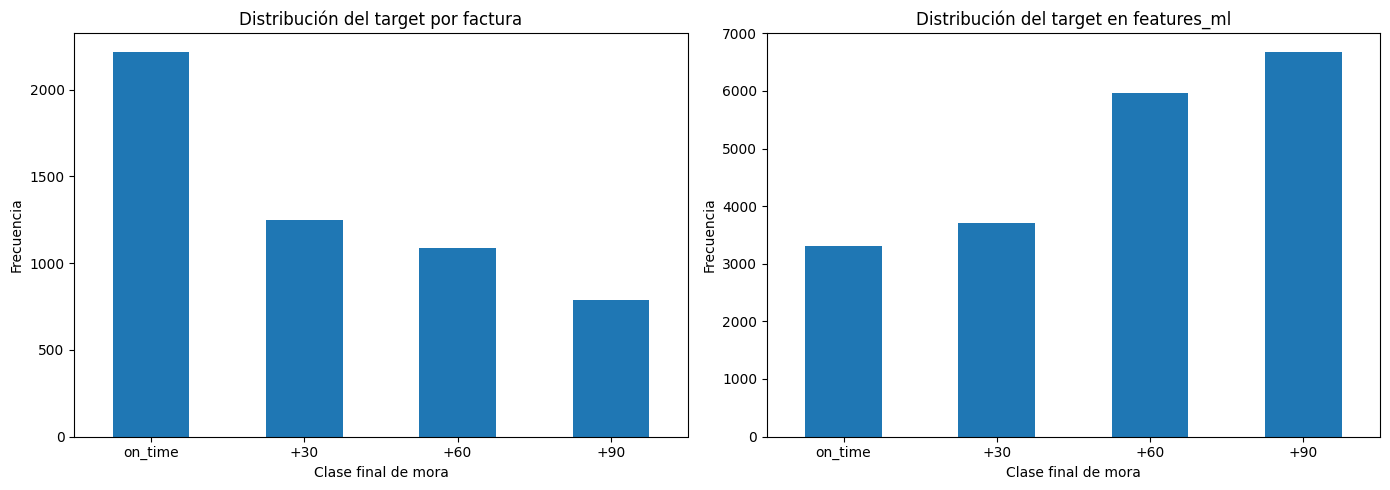

In [11]:
# Gráficos de distribución principales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

facturas[fact_target_col].value_counts().reindex(orden_target).plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución del target por factura')
axes[0].set_xlabel('Clase final de mora')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

features[features_target_col].value_counts().reindex(orden_target).plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribución del target en features_ml')
axes[1].set_xlabel('Clase final de mora')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


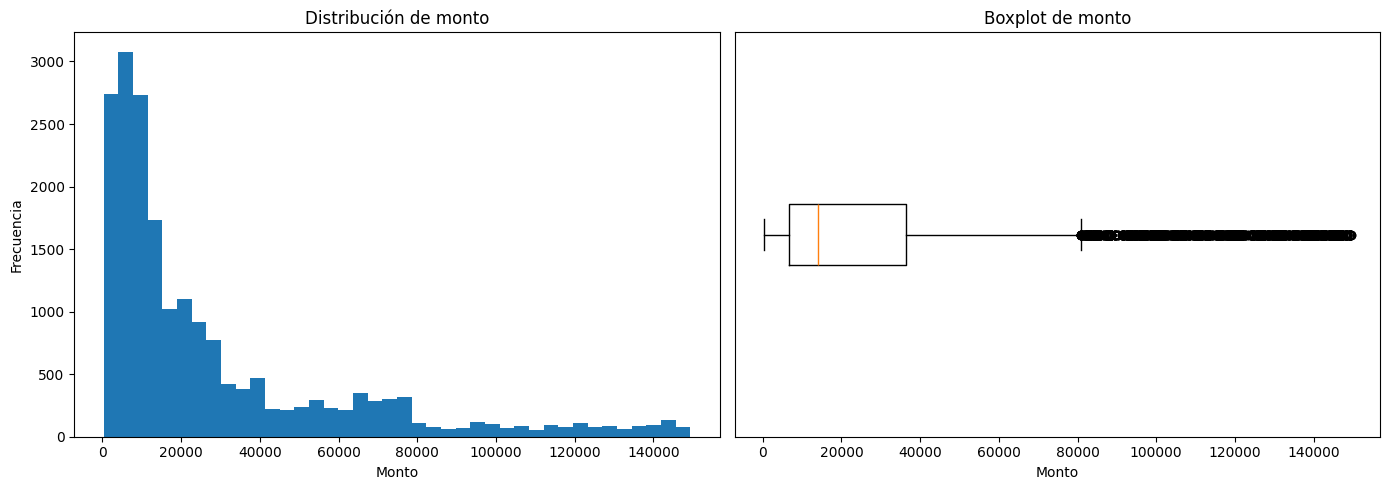

In [12]:

# Histograma y boxplot para monto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features['monto'].dropna(), bins=40)
axes[0].set_title('Distribución de monto')
axes[0].set_xlabel('Monto')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(features['monto'].dropna(), vert=False)
axes[1].set_title('Boxplot de monto')
axes[1].set_xlabel('Monto')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()



### Interpretación de distribuciones

- El `target` debe revisarse tanto a nivel de factura como a nivel de `features_ml`, porque el segundo dataset replica facturas en múltiples cortes.
- Si las clases severas (`+60`, `+90`) aparecen sobrerrepresentadas en `features_ml`, eso no necesariamente implica error: suele deberse a que las facturas más problemáticas generan más gestiones y más cortes.
- La distribución de `monto` debe observarse con cuidado porque influye directamente en priorización y porque puede introducir valores extremos plausibles de negocio.


In [13]:
# Conexión explícita entre distribuciones y decisiones de preprocessing/algoritmo
distribution_decisions = pd.DataFrame([
    {
        'hallazgo_distribucion': 'Clases severas sobrerrepresentadas en features_ml por múltiples cortes',
        'riesgo_modelado': 'Métricas globales como accuracy pueden ocultar mal desempeño por clase',
        'decision_preprocessing_algoritmo': 'Usar F1-macro, reporte por clase y evaluar class_weight o balanceo solo dentro de train.'
    },
    {
        'hallazgo_distribucion': 'Una misma factura aparece en varios cortes temporales',
        'riesgo_modelado': 'Fuga de información si train/test se separa por fila',
        'decision_preprocessing_algoritmo': 'Aplicar split agrupado por factura_id; todos los cortes de una factura quedan en el mismo conjunto.'
    },
    {
        'hallazgo_distribucion': 'monto y ratio_monto muestran asimetría positiva y cola derecha',
        'riesgo_modelado': 'Modelos lineales o basados en distancia pueden quedar dominados por escala y extremos',
        'decision_preprocessing_algoritmo': 'Evaluar log1p o RobustScaler para modelos lineales/distancia; árboles pueden usar valores originales.'
    },
    {
        'hallazgo_distribucion': 'dias_hasta_vence contiene valores negativos',
        'riesgo_modelado': 'Puede interpretarse erróneamente como dato inválido',
        'decision_preprocessing_algoritmo': 'Conservarlo porque indica cortes posteriores al vencimiento; opcionalmente crear indicador vencida_en_corte.'
    },
    {
        'hallazgo_distribucion': 'Nulos de última gestión concentrados en corte 0',
        'riesgo_modelado': 'Eliminar filas descartaría el inicio del ciclo de vida de todas las facturas',
        'decision_preprocessing_algoritmo': 'Imputar con sentinela e indicador de ausencia de gestión previa.'
    },
])

distribution_decisions.to_csv(OUTPUTS_DIR / 'distribution_preprocessing_decisions.csv', index=False, encoding='utf-8')
display(distribution_decisions)


,hallazgo_distribucion,riesgo_modelado,decision_preprocessing_algoritmo
0,Clases severas sobrerrepresentadas en features...,Métricas globales como accuracy pueden ocultar...,"Usar F1-macro, reporte por clase y evaluar cla..."
1,Una misma factura aparece en varios cortes tem...,Fuga de información si train/test se separa po...,Aplicar split agrupado por factura_id; todos l...
2,monto y ratio_monto muestran asimetría positiv...,Modelos lineales o basados en distancia pueden...,Evaluar log1p o RobustScaler para modelos line...
3,dias_hasta_vence contiene valores negativos,Puede interpretarse erróneamente como dato inv...,Conservarlo porque indica cortes posteriores a...
4,Nulos de última gestión concentrados en corte 0,Eliminar filas descartaría el inicio del ciclo...,Imputar con sentinela e indicador de ausencia ...


## 5. Identificación de valores atípicos (Outliers)

In [14]:
# Detección de outliers por IQR
vars_outliers = [
    'monto', 'monto_promedio_hist', 'ratio_monto', 'mora_promedio_hist',
    'mora_ultimo_tramo', 'tasa_cumplimiento', 'num_facturas_prev',
    'moras_consecutivas', 'num_gestiones_factura', 'dias_desde_emision',
    'dias_hasta_vence', 'tasa_contacto_cliente', 'num_no_contesta_cons',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total'
]

outlier_rows = []
for col in vars_outliers:
    q1 = features[col].quantile(0.25)
    q3 = features[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (features[col] < low) | (features[col] > high)
    outlier_rows.append({
        'variable': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior_iqr': low,
        'limite_superior_iqr': high,
        'min': features[col].min(),
        'max': features[col].max(),
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(mask.mean() * 100, 2),
        'decision_eda': 'Documentar y conservar; revisar transformación robusta si el algoritmo es sensible a escala.'
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values(['pct_outliers', 'n_outliers'], ascending=False)
outliers_df.to_csv(OUTPUTS_DIR / 'outlier_summary.csv', index=False, encoding='utf-8')
display(outliers_df)


,variable,q1,q3,iqr,limite_inferior_iqr,limite_superior_iqr,min,max,n_outliers,pct_outliers,decision_eda
11,tasa_contacto_cliente,0.4634,0.6061,0.1427,0.2493,0.8201,0.0000,1.0000,1598,8.1200,Documentar y conservar; revisar transformación...
0,monto,"6,641.3400","36,312.9200","29,671.5800","-37,866.0300","80,820.2900",318.9600,"149,413.9900",1551,7.8800,Documentar y conservar; revisar transformación...
13,num_promesas_rotas,0.0000,4.0000,4.0000,-6.0000,10.0000,0.0000,21.0000,951,4.8300,Documentar y conservar; revisar transformación...
12,num_no_contesta_cons,0.0000,1.0000,1.0000,-1.5000,2.5000,0.0000,8.0000,916,4.6600,Documentar y conservar; revisar transformación...
7,moras_consecutivas,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,27.0000,670,3.4100,Documentar y conservar; revisar transformación...
15,promesas_total,1.0000,8.0000,7.0000,-9.5000,18.5000,0.0000,32.0000,541,2.7500,Documentar y conservar; revisar transformación...
2,ratio_monto,0.5587,1.4885,0.9297,-0.8359,2.8831,0.0258,22.8089,292,1.4800,Documentar y conservar; revisar transformación...
1,monto_promedio_hist,"7,066.3100","42,436.9300","35,370.6200","-45,989.6200","95,492.8600",514.3300,"140,522.2100",194,0.9900,Documentar y conservar; revisar transformación...
4,mora_ultimo_tramo,0.0000,35.0000,35.0000,-52.5000,87.5000,0.0000,119.0000,81,0.4100,Documentar y conservar; revisar transformación...
3,mora_promedio_hist,3.7500,42.1400,38.3900,-53.8350,99.7250,0.0000,119.0000,38,0.1900,Documentar y conservar; revisar transformación...


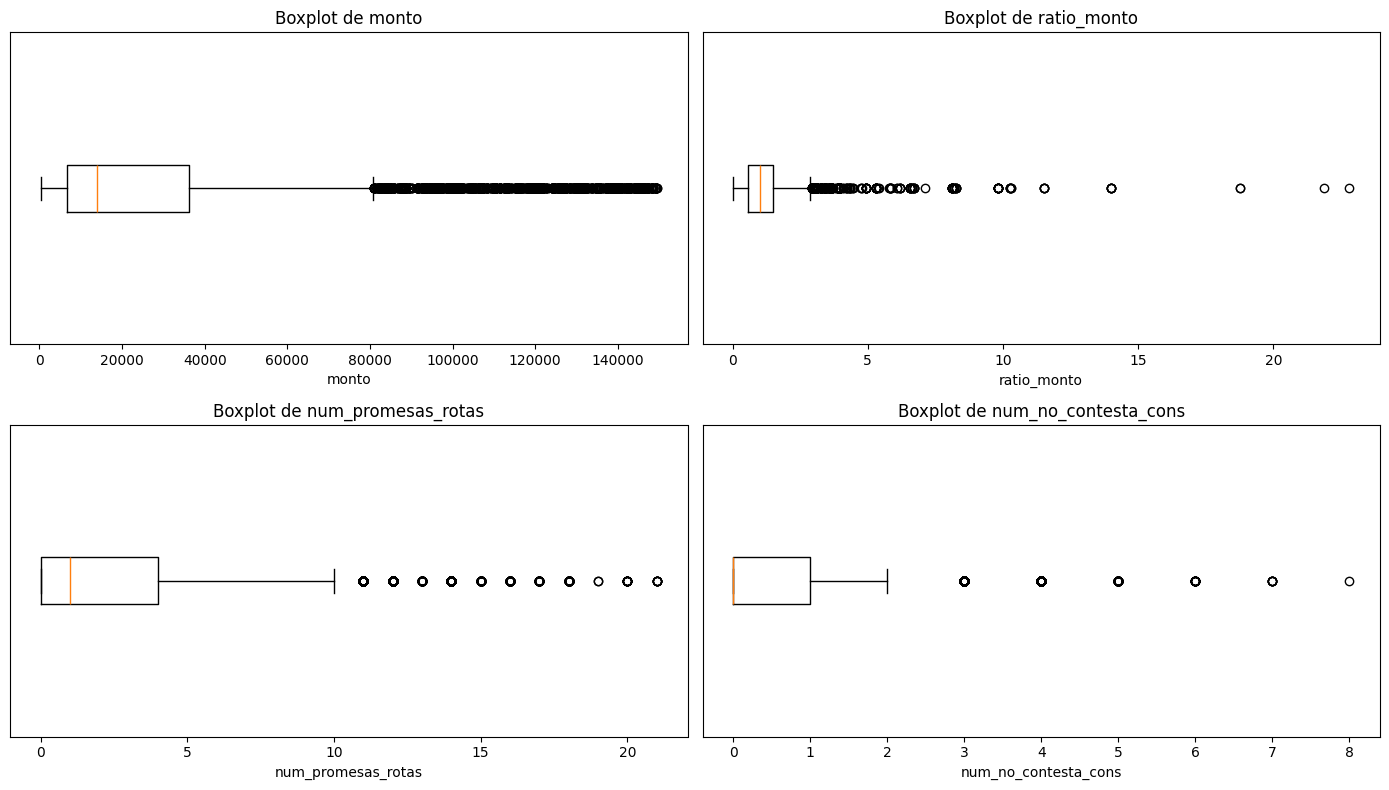

In [15]:

# Boxplots de variables seleccionadas con mayor interés
seleccion_box = ['monto', 'ratio_monto', 'num_promesas_rotas', 'num_no_contesta_cons']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.ravel(), seleccion_box):
    ax.boxplot(features[col].dropna(), vert=False)
    ax.set_title(f'Boxplot de {col}')
    ax.set_xlabel(col)
    ax.set_yticks([])

plt.tight_layout()
plt.show()



### Interpretación de outliers

- La presencia de outliers no implica automáticamente error de captura.
- En este problema, variables como `monto`, `ratio_monto`, `num_promesas_rotas` o `num_no_contesta_cons` pueden contener casos extremos **reales y valiosos** para el modelo.
- Por tanto, la decisión metodológica recomendada es **no eliminarlos de forma automática**. Lo apropiado es documentarlos y, si se entrena un modelo sensible a escala, aplicar transformaciones o escalado robusto.


## 6. Análisis de correlaciones

In [16]:
# Correlación de variables numéricas y con target ordinal
map_target = {'on_time': 0, '+30': 1, '+60': 2, '+90': 3}
features_corr = features.copy()
features_corr['target_ord'] = features_corr[features_target_col].map(map_target)

num_cols = features_corr.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = features_corr[num_cols].corr()

top_corr_target = correlation_matrix['target_ord'].drop('target_ord').sort_values(key=np.abs, ascending=False).head(15)
top_corr_target.to_frame('corr').to_csv(OUTPUTS_DIR / 'correlation_with_target.csv', encoding='utf-8')
display(top_corr_target.to_frame('corr'))


,corr
num_corte,0.5709
num_gestiones_factura,0.5709
dias_hasta_vence,-0.5670
dias_desde_emision,0.5543
tasa_cumplimiento,-0.4050
mora_promedio_hist,0.3856
mora_ultimo_tramo,0.3548
tasa_cumpl_promesas,-0.3042
num_promesas_rotas,0.2681
tiene_garantia,-0.2566


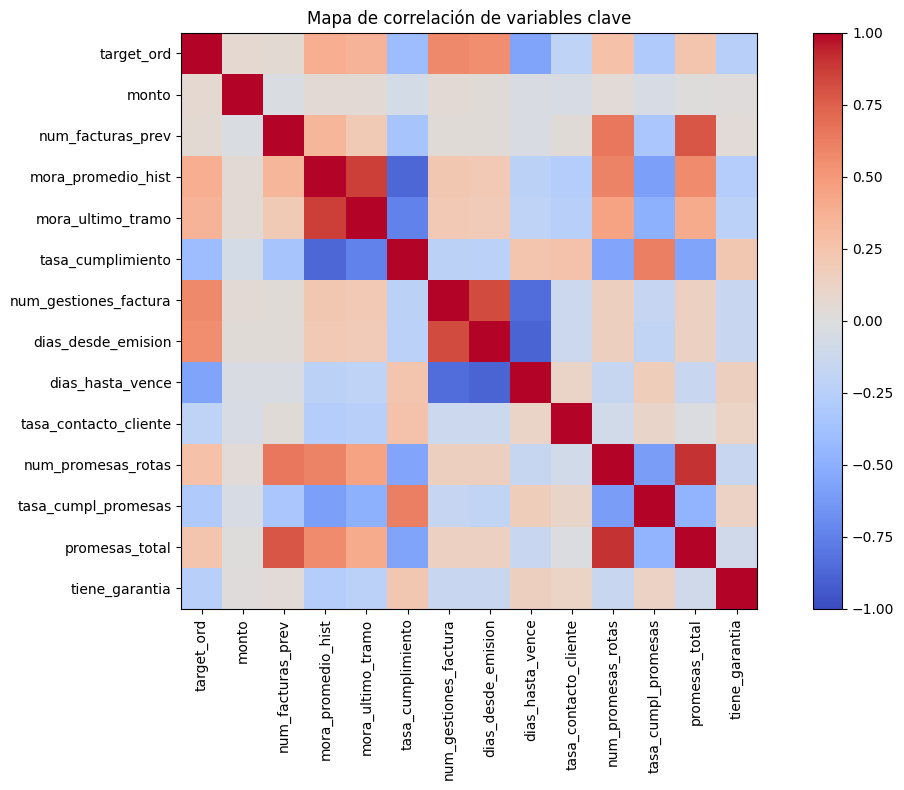

In [17]:

# Heatmap de correlación en variables clave
cols_heatmap = [
    'target_ord', 'monto', 'num_facturas_prev', 'mora_promedio_hist',
    'mora_ultimo_tramo', 'tasa_cumplimiento', 'num_gestiones_factura',
    'dias_desde_emision', 'dias_hasta_vence', 'tasa_contacto_cliente',
    'num_promesas_rotas', 'tasa_cumpl_promesas', 'promesas_total',
    'tiene_garantia'
]

corr_show = features_corr[cols_heatmap].corr()
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(corr_show, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_show.columns)))
ax.set_xticklabels(corr_show.columns, rotation=90)
ax.set_yticks(range(len(corr_show.index)))
ax.set_yticklabels(corr_show.index)
ax.set_title('Mapa de correlación de variables clave')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [18]:

# Pares de alta correlación entre predictores
pred_cols = [c for c in num_cols if c != 'target_ord']
corr_pred = features_corr[pred_cols].corr().abs()
mask = np.triu(np.ones_like(corr_pred, dtype=bool), k=1)
high_pairs = (
    corr_pred.where(mask)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)

display(high_pairs.head(15))


,var1,var2,abs_corr
20,num_corte,num_gestiones_factura,1.0000
959,num_promesas_rotas,promesas_total,0.9045
727,dias_desde_emision,dias_hasta_vence,0.8862
464,mora_promedio_hist,tasa_cumplimiento,0.8687
463,mora_promedio_hist,mora_ultimo_tramo,0.8595
663,num_gestiones_factura,dias_hasta_vence,0.8465
23,num_corte,dias_hasta_vence,0.8465
273,sector_construccion,monto_promedio_hist,0.8319
662,num_gestiones_factura,dias_desde_emision,0.8226
22,num_corte,dias_desde_emision,0.8226



### Interpretación de correlaciones

- Las correlaciones con `target_ord` ayudan a identificar variables con mayor señal explicativa del riesgo.
- Correlaciones muy altas entre predictores sugieren **redundancia** y deben tenerse en cuenta antes del entrenamiento, especialmente si se usará Regresión Logística Multinomial.
- En modelos basados en árboles la multicolinealidad suele ser menos problemática, pero igual conviene documentarla porque afecta interpretación y diseño del pipeline.


## 7. Análisis de variables categóricas

In [19]:
# Frecuencias categoricas relevantes para el EDA

def freq_table(series):
    tab = series.value_counts(dropna=False).rename_axis(series.name).reset_index(name='count')
    tab['pct'] = (tab['count'] / len(series) * 100).round(2)
    return tab

for titulo, serie in [
    ('Sector de clientes', clientes['sector']),
    ('Canal de gestion', gestiones['canal']),
    ('Resultado de gestion', gestiones['resultado']),
    ('Target por factura', facturas[fact_target_col]),
    ('Target en features_ml', features[features_target_col])
]:
    display(Markdown(f'### {titulo}'))
    display(freq_table(serie))


### Sector de clientes

,sector,count,pct
0,construccion,35,17.5000
1,manufactura,34,17.0000
2,salud,27,13.5000
3,agro,24,12.0000
4,transporte,24,12.0000
5,retail,21,10.5000
6,tecnologia,18,9.0000
7,servicios,17,8.5000


### Canal de gestion

,canal,count,pct
0,whatsapp,4221,29.4500
1,llamada,3854,26.8900
2,email,2704,18.8700
3,visita,2255,15.7300
4,carta_notarial,1299,9.0600


### Resultado de gestion

,resultado,count,pct
0,no_contesta,5010,34.9500
1,promesa_de_pago,1741,12.1500
2,rechazo_pago,1592,11.1100
3,en_proceso_interno,1403,9.7900
4,disputa_monto,1294,9.0300
5,cliente_ausente,1242,8.6700
6,confirma_pago,1098,7.6600
7,pagado,509,3.5500
8,numero_invalido,444,3.1000


### Target por factura

,target_mora,count,pct
0,on_time,2217,41.5300
1,+30,1246,23.3400
2,+60,1088,20.3800
3,+90,787,14.7400


### Target en features_ml

,target_mora,count,pct
0,+90,6676,33.9400
1,+60,5965,30.3200
2,+30,3713,18.8800
3,on_time,3317,16.8600


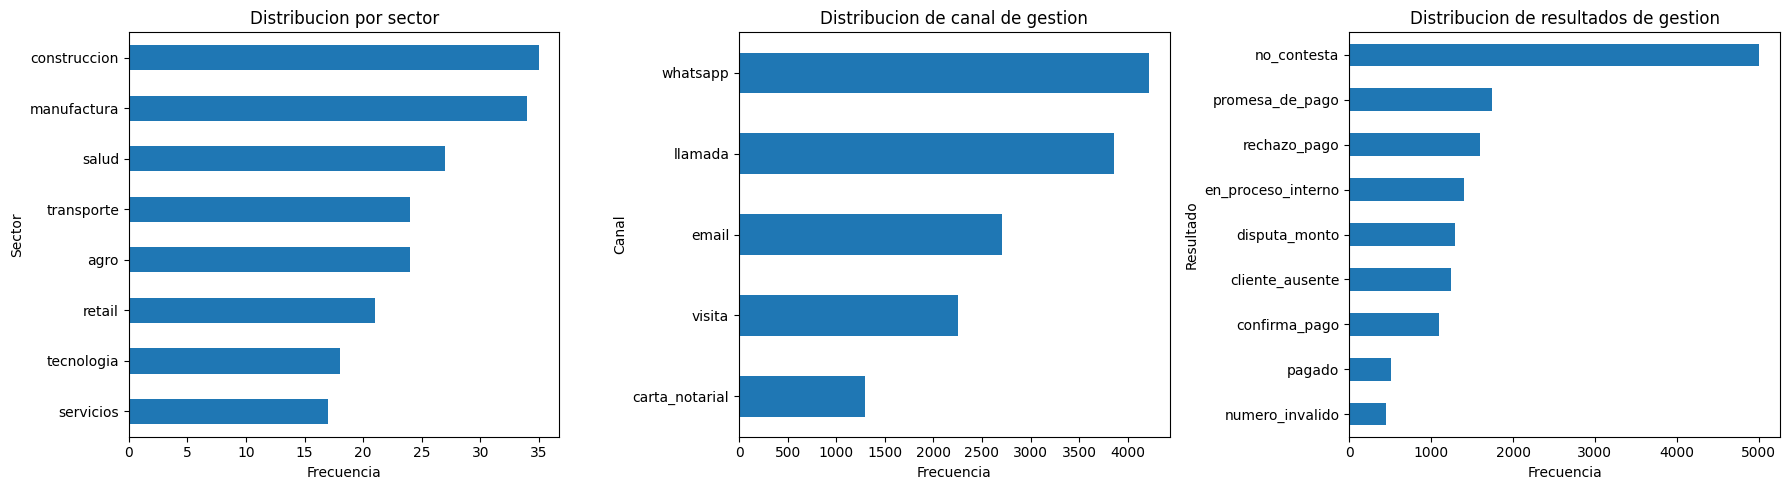

In [20]:
# Graficos de variables categoricas principales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clientes['sector'].value_counts().sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Distribucion por sector')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Sector')

gestiones['canal'].value_counts().sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Distribucion de canal de gestion')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Canal')

gestiones['resultado'].value_counts().sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Distribucion de resultados de gestion')
axes[2].set_xlabel('Frecuencia')
axes[2].set_ylabel('Resultado')

plt.tight_layout()
plt.show()



### Interpretacion de categoricas

- La distribucion por `sector` describe la composicion de la cartera y ayuda a verificar que no exista concentracion extrema en un unico tipo de cliente.
- La distribucion por `canal` muestra la intensidad relativa de los medios de gestion y permite contrastar si la estrategia operativa esta dominada por contactos remotos o acciones presenciales/formales.
- La distribucion de `resultado` resume la efectividad operativa inicial: una frecuencia alta de no contacto o rechazo anticipa dificultades de cobranza y debe considerarse en preparacion/modelado.
- `perfil_pago` se reconoce como variable interna artificial de la simulacion; por eso no se interpreta como predictor ni se cruza con el target.


## 8. Relaciones entre variables

In [21]:

# Relación target vs garantía
facturas_con_garantia = facturas.merge(clientes[['cliente_id', 'tiene_garantia']], on='cliente_id', how='left')
rel_garantia = pd.crosstab(
    facturas_con_garantia['tiene_garantia'],
    facturas_con_garantia[fact_target_col],
    normalize='index'
).round(3)
display(Markdown('### Target por garantía'))
display(rel_garantia)


### Target por garantía

target_mora,+30,+60,+90,on_time
tiene_garantia,,,,
0,0.2530,0.2460,0.1980,0.3040
1,0.2050,0.1440,0.0750,0.5760


In [22]:
# Relaciones operativas con target y resultados de gestion
rel_condicion = pd.crosstab(facturas['condicion_dias'], facturas[fact_target_col], normalize='index').round(3)
rel_contacto = pd.crosstab(gestiones['contacto_exitoso'], gestiones['resultado'], normalize='index').round(3)

display(Markdown('### Target por condicion de pago'))
display(rel_condicion)

display(Markdown('### Resultado de gestion segun contacto exitoso'))
display(rel_contacto)


### Target por condicion de pago

target_mora,+30,+60,+90,on_time
condicion_dias,,,,
30,0.2400,0.2170,0.1400,0.4040
45,0.2220,0.2090,0.1460,0.4220
60,0.2370,0.1820,0.1470,0.4350
90,0.2340,0.2080,0.1570,0.4020


### Resultado de gestion segun contacto exitoso

resultado,cliente_ausente,confirma_pago,disputa_monto,en_proceso_interno,no_contesta,numero_invalido,pagado,promesa_de_pago,rechazo_pago
contacto_exitoso,,,,,,,,,
0,0.1850,0.0000,0.0000,0.0000,0.7480,0.0660,0.0000,0.0000,0.0000
1,0.0000,0.1440,0.1690,0.1840,0.0000,0.0000,0.0670,0.2280,0.2080


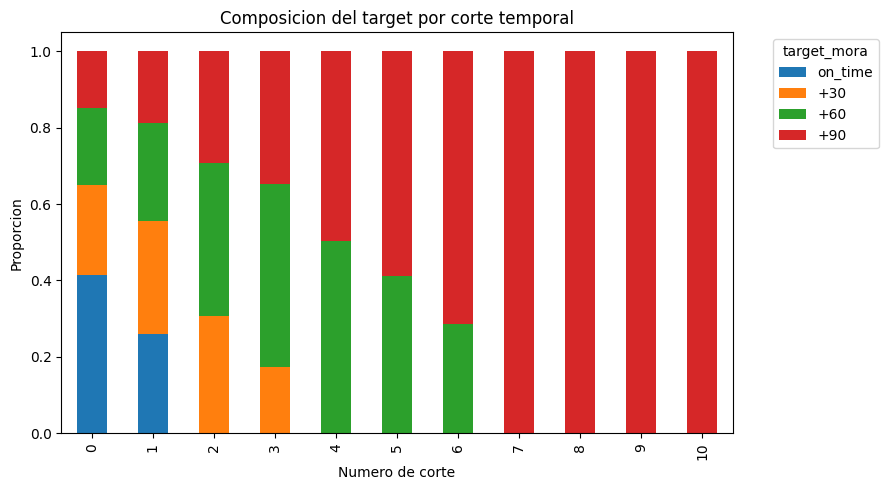

In [23]:
# Relacion visual entre corte temporal y composicion del target
fig, ax = plt.subplots(figsize=(9, 5))

orden_corte = sorted(features['num_corte'].dropna().unique())
target_por_corte = pd.crosstab(features['num_corte'], features[features_target_col], normalize='index').reindex(orden_corte)
target_por_corte[orden_target].plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Composicion del target por corte temporal')
ax.set_xlabel('Numero de corte')
ax.set_ylabel('Proporcion')
ax.legend(title=features_target_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



### Lectura de relaciones

- La relacion entre `num_corte` y `target` permite observar como cambia la composicion del riesgo conforme avanza el ciclo de cobranza.
- El cruce entre `contacto_exitoso` y `resultado` es una validacion operativa importante: ayuda a verificar que el catalogo de resultados sea consistente.
- El analisis no usa `perfil_pago` contra el target porque esa variable pertenece a la logica interna de generacion sintetica y podria inducir una lectura circular.


## 9. Identificación de problemas para el modelado

In [24]:
# Resumen de problemas y decisiones metodológicas
severe_pct = (features[features_target_col].isin(['+60', '+90']).mean() * 100)

problemas_modelado = pd.DataFrame([
    {
        'problema_detectado': 'Desbalance de clases en features_ml',
        'evidencia': f'+60 y +90 representan {severe_pct:.2f}% de las filas',
        'impacto': 'Puede sesgar el entrenamiento y favorecer clases mayoritarias',
        'recomendacion': 'Usar F1-macro como métrica principal y evaluar class_weight o balanceo dentro de train'
    },
    {
        'problema_detectado': 'Redundancia entre variables temporales y de gestión',
        'evidencia': 'num_corte y num_gestiones_factura capturan información muy cercana',
        'impacto': 'Aumenta redundancia y dificulta interpretación',
        'recomendacion': 'Conservar num_gestiones_factura como variable operativa principal y evaluar num_corte en análisis de sensibilidad'
    },
    {
        'problema_detectado': 'Nulos estructurales en corte 0',
        'evidencia': 'dias_desde_ultima_gestion y ultimo_resultado_enc no aplican antes de la primera gestión',
        'impacto': 'Exige estrategia explícita de imputación o indicador de ausencia',
        'recomendacion': 'Imputar con valor sentinela y agregar indicador binario de ausencia'
    },
    {
        'problema_detectado': 'Outliers plausibles de negocio',
        'evidencia': 'monto, ratio_monto y num_promesas_rotas muestran valores extremos bajo IQR',
        'impacto': 'Pueden influir en modelos sensibles a escala',
        'recomendacion': 'No eliminar automáticamente; usar escalado robusto o transformación log si corresponde'
    },
    {
        'problema_detectado': 'Múltiples filas por factura',
        'evidencia': 'features_ml contiene cortes temporales por factura',
        'impacto': 'Existe riesgo de fuga si el split se hace por fila',
        'recomendacion': 'Dividir train/test por factura_id, no por fila'
    },
    {
        'problema_detectado': 'Variable perfil_pago es interna de simulación',
        'evidencia': 'Aparece en clientes y explica coherentemente el target, pero no representa necesariamente una variable real disponible',
        'impacto': 'Puede inflar artificialmente el desempeño si entra al modelo final',
        'recomendacion': 'Usarla solo para validación conceptual de la simulación; excluirla del set de features finales'
    },
])

problemas_modelado.to_csv(OUTPUTS_DIR / 'modeling_risks_and_decisions.csv', index=False, encoding='utf-8')
display(problemas_modelado)


,problema_detectado,evidencia,impacto,recomendacion
0,Desbalance de clases en features_ml,+60 y +90 representan 64.26% de las filas,Puede sesgar el entrenamiento y favorecer clas...,Usar F1-macro como métrica principal y evaluar...
1,Redundancia entre variables temporales y de ge...,num_corte y num_gestiones_factura capturan inf...,Aumenta redundancia y dificulta interpretación,Conservar num_gestiones_factura como variable ...
2,Nulos estructurales en corte 0,dias_desde_ultima_gestion y ultimo_resultado_e...,Exige estrategia explícita de imputación o ind...,Imputar con valor sentinela y agregar indicado...
3,Outliers plausibles de negocio,"monto, ratio_monto y num_promesas_rotas muestr...",Pueden influir en modelos sensibles a escala,No eliminar automáticamente; usar escalado rob...
4,Múltiples filas por factura,features_ml contiene cortes temporales por fac...,Existe riesgo de fuga si el split se hace por ...,"Dividir train/test por factura_id, no por fila"
5,Variable perfil_pago es interna de simulación,Aparece en clientes y explica coherentemente e...,Puede inflar artificialmente el desempeño si e...,Usarla solo para validación conceptual de la s...


In [25]:
# Selección final sugerida de variables para preparación/modelado
id_cols = {'factura_id', 'cliente_id', 'fecha_corte'}
target_cols = {features_target_col}
redundancy_review = {'num_corte', 'ratio_monto', 'mora_ultimo_tramo', 'promesas_total'}
structural_missing_cols = {'dias_desde_ultima_gestion', 'ultimo_resultado_enc'}

feature_rows = []
for col in features.columns:
    if col in target_cols:
        decision = 'excluir_target'
        reason = 'Etiqueta supervisada; usar solo como y.'
    elif col in id_cols:
        decision = 'excluir_identificador'
        reason = 'Llave/trazabilidad; no aporta patrón generalizable como predictor directo.'
    elif col in structural_missing_cols:
        decision = 'mantener_con_imputacion'
        reason = 'Nulo estructural de corte 0; debe codificarse sin eliminar filas.'
    elif col in redundancy_review:
        decision = 'evaluar_por_redundancia'
        reason = 'Aporta señal, pero puede duplicar información de otra variable cercana.'
    elif pd.api.types.is_numeric_dtype(features[col]):
        decision = 'mantener_base'
        reason = 'Variable numérica disponible al corte y potencialmente predictiva.'
    else:
        decision = 'revisar_codificacion'
        reason = 'Variable no numérica; requiere codificación o exclusión justificada.'
    feature_rows.append({'variable': col, 'decision_sugerida': decision, 'justificacion': reason})

feature_selection = pd.DataFrame(feature_rows)
selected_features_base = feature_selection.loc[
    feature_selection['decision_sugerida'].isin(['mantener_base', 'mantener_con_imputacion']),
    'variable'
].tolist()

feature_selection.to_csv(OUTPUTS_DIR / 'feature_selection_recommendation.csv', index=False, encoding='utf-8')
pd.Series(selected_features_base, name='feature').to_csv(OUTPUTS_DIR / 'selected_features_base.csv', index=False, encoding='utf-8')

print('Número de variables base sugeridas:', len(selected_features_base))
display(feature_selection)
display(pd.DataFrame({'selected_features_base': selected_features_base}))


Número de variables base sugeridas: 28


,variable,decision_sugerida,justificacion
0,factura_id,excluir_identificador,Llave/trazabilidad; no aporta patrón generaliz...
1,cliente_id,excluir_identificador,Llave/trazabilidad; no aporta patrón generaliz...
2,num_corte,evaluar_por_redundancia,"Aporta señal, pero puede duplicar información ..."
3,fecha_corte,excluir_identificador,Llave/trazabilidad; no aporta patrón generaliz...
4,monto,mantener_base,Variable numérica disponible al corte y potenc...
5,condicion_dias,mantener_base,Variable numérica disponible al corte y potenc...
6,antiguedad_meses,mantener_base,Variable numérica disponible al corte y potenc...
7,tiene_garantia,mantener_base,Variable numérica disponible al corte y potenc...
8,sector_retail,mantener_base,Variable numérica disponible al corte y potenc...
9,sector_manufactura,mantener_base,Variable numérica disponible al corte y potenc...


,selected_features_base
0,monto
1,condicion_dias
2,antiguedad_meses
3,tiene_garantia
4,sector_retail
5,sector_manufactura
6,sector_servicios
7,sector_construccion
8,sector_agro
9,sector_tecnologia
